# 09 — Estimation de la distance a un AP WiFi

Ce notebook documente l'algorithme d'estimation de distance et entraine (si possible) des regresseurs ML supervises.

## 1. Donnees disponibles

Le fichier `data/exports/RSSI0.xlsx` contient **un seul scan** (timestamp `2026-02-13 10:11:57.1`) capturant 73 BSSID a un emplacement de reference.
Il s'agit en pratique des RSSI a une distance proche d'un AP de reference (`d0 ≈ 1 m` par convention).

Implications :
- **Pas de couples (RSSI, distance vraie) labellises** → impossible d'entrainer un regresseur ML supervise classique sans plus de donnees.
- → On utilise un **modele physique de propagation log-distance**, qui ne necessite que la calibration de `n` (path loss exponent).
- Si l'utilisateur capture ulterieurement des couples (RSSI, distance) en `data/distance/<bssid>.csv` (colonnes `rssi`, `distance`), un cadre ML est fourni en section 4.

## 2. Modele physique : log-distance path loss

$$ \text{PL}(d) = \text{PL}(d_0) + 10 \cdot n \cdot \log_{10}\left( \frac{d}{d_0} \right) $$

$$ \text{RSSI}(d) = \text{RSSI}(d_0) - 10 \cdot n \cdot \log_{10}\left( \frac{d}{d_0} \right) $$

$$ \boxed{ \; d \;=\; d_0 \cdot 10^{\frac{\text{RSSI}(d_0) - \text{RSSI}(d)}{10\,n}} \; } $$

Avec :
- `d0`   : distance de reference (1 m).
- `RSSI(d0)` : RSSI mesure a la distance `d0` (donnee `RSSI0.xlsx`).
- `n`    : path loss exponent.
    - `n = 2.0` : espace libre.
    - `n = 3.0` : interieur typique (cloisons legeres).
    - `n = 4.0` : interieur dense (beton, multi-cloisons).

Quand un BSSID est inconnu (absent de `RSSI0.xlsx`), on utilise un RSSI de reference par defaut (`-45 dBm`).

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

_SRC = (Path.cwd().parent / 'src').resolve()
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from distance_estimator import (LogDistanceEstimator, save_distance_artifacts,
                                 train_supervised_regressor)

### 2.1 Chargement de la reference

In [2]:
ref_df = pd.read_excel('../data/exports/RSSI0.xlsx')
print('shape:', ref_df.shape)
print('BSSID uniques:', ref_df['BSSID'].nunique())
print('SSID uniques:', ref_df['SSID'].dropna().nunique())
print('RSSI range:', ref_df['RSSI'].min(), 'a', ref_df['RSSI'].max(), 'dBm')
ref_df.head()

shape: (104, 4)
BSSID uniques: 73
SSID uniques: 7
RSSI range: -88 a -36 dBm


,Time,SSID,BSSID,RSSI
0,2026-02-13 10:11:57.1,UTTetudiants,84:b2:61:1f:b5:37:,-59
1,2026-02-13 10:11:57.1,UTTetudiants,f8:6b:d9:5e:10:c8:,-42
2,2026-02-13 10:11:57.1,UTTetudiants,f8:6b:d9:01:93:67:,-79
3,2026-02-13 10:11:57.1,UTTetudiants,e4:aa:5d:bf:25:58:,-74
4,2026-02-13 10:11:57.1,UTTetudiants,e4:aa:5d:fd:3e:e7:,-75


In [3]:
estimator = LogDistanceEstimator.from_reference_dataframe(ref_df, n=3.0, d0=1.0)
print(f'Estimator construit : n={estimator.n}, d0={estimator.d0}m, '
      f'{len(estimator.known_bssids())} BSSID connus.')

Estimator construit : n=3.0, d0=1.0m, 73 BSSID connus.


### 2.2 Tests de coherence

Verifions que la formule respecte les invariants attendus.

In [4]:
b = estimator.known_bssids()[0]
rssi_ref = estimator.rssi_ref[b]
for delta_db, expected_d in [(0, 1.0), (10*estimator.n, 10.0), (20*estimator.n, 100.0)]:
    d = estimator.estimate(b, rssi_ref - delta_db)
    print(f'  RSSI={rssi_ref-delta_db:+.1f} dBm (delta={delta_db:+.1f}) → d={d:.3f} m   (attendu {expected_d} m)')
assert abs(estimator.estimate(b, rssi_ref) - 1.0) < 1e-6, 'invariant a d0 viole'
print('OK')

  RSSI=-81.0 dBm (delta=+0.0) → d=1.000 m   (attendu 1.0 m)
  RSSI=-111.0 dBm (delta=+30.0) → d=10.000 m   (attendu 10.0 m)
  RSSI=-141.0 dBm (delta=+60.0) → d=100.000 m   (attendu 100.0 m)
OK


### 2.3 Visualisation : distance vs RSSI

Effet de `n` sur la courbe.

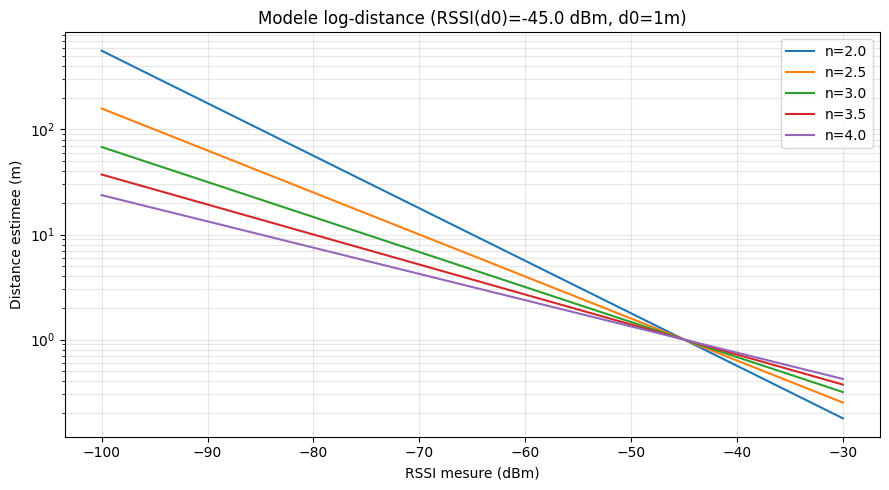

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
rssi_grid = np.linspace(-30, -100, 200)
ref_demo = -45.0
for n in [2.0, 2.5, 3.0, 3.5, 4.0]:
    distances = 10.0 ** ((ref_demo - rssi_grid) / (10.0 * n))
    ax.plot(rssi_grid, distances, label=f'n={n:.1f}')
ax.set_xlabel('RSSI mesure (dBm)')
ax.set_ylabel('Distance estimee (m)')
ax.set_yscale('log')
ax.set_title(f'Modele log-distance (RSSI(d0)={ref_demo} dBm, d0=1m)')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Estimation pour un scan reel

Petit exemple : on prend un scan parmi `data/raw/` (par ex. P101A) et on estime la distance a chaque AP visible.

In [6]:
sample = pd.read_csv('../data/raw/wifi_P101A.csv')
first_time = sample['Time'].iloc[0]
snap = sample[sample['Time'] == first_time].copy()
scan = dict(zip(snap['BSSID'].astype(str).str.rstrip(':').str.lower(), snap['RSSI(dBm)']))
results = estimator.estimate_many(scan)
df_results = pd.DataFrame(results).head(10)
df_results

,bssid,ssid,rssi_measured,rssi_ref,distance_m,known
0,70:61:7b:e9:ac:25,DT-cyber,-68.0,-80.0,0.398107,True
1,70:61:7b:e9:ac:21,UTT,-70.0,-81.0,0.429866,True
2,84:b2:61:08:fc:c7,UTTetudiants,-56.0,-66.0,0.464159,True
3,70:61:7b:e9:ac:2d,eduroam,-68.0,-78.0,0.464159,True
4,70:61:7b:e9:ac:2e,UTT,-68.0,-78.0,0.464159,True
5,84:b2:61:1f:b5:38,UTTetudiants,-75.0,-85.0,0.464159,True
6,70:61:7b:e9:ac:22,eduroam,-70.0,-79.0,0.501187,True
7,70:61:7b:e9:ac:28,UTTetudiants,-70.0,-77.0,0.584341,True
8,70:61:7b:e9:ac:27,UTTetudiants,-68.0,-75.0,0.584341,True
9,70:61:7b:e9:ac:2a,DT-cyber,-70.0,-77.0,0.584341,True


## 3. Calibration de `n`

Si on dispose de mesures (rssi, distance) verifiees, on peut estimer le `n` optimal.
Demonstration avec des donnees synthetiques (puisqu'on n'a pas de mesures terrain pour l'instant).

In [7]:
rng = np.random.default_rng(42)
true_n = 2.7
calib_samples = []
for d_true in [1.0, 2.0, 3.0, 5.0, 7.5, 10.0, 15.0]:
    bssid = estimator.known_bssids()[0]
    rssi_ref = estimator.rssi_ref[bssid]
    rssi = rssi_ref - 10 * true_n * np.log10(d_true / 1.0) + rng.normal(0, 1.5)
    calib_samples.append({'bssid': bssid, 'rssi': float(rssi), 'distance': d_true})
n_opt = estimator.calibrate_n(calib_samples)
print(f'n optimal estime : {n_opt:.3f}  (vrai : {true_n})')
estimator.n = n_opt

n optimal estime : 2.782  (vrai : 2.7)


## 4. Cadre ML supervise (optionnel)

Si vous capturez de vraies paires `(rssi, distance)` pour un ou plusieurs BSSID, deposez-les dans `data/distance/*.csv` au format :

```
bssid,rssi,distance
84:b2:61:1f:b5:37,-67,3.2
...
```

La cellule ci-dessous detecte ces fichiers et entraine 3 regresseurs (`LinearRegression`, `RandomForest`, `GradientBoosting`).

In [8]:
DIST_DIR = Path('../data/distance')
csvs = sorted(DIST_DIR.glob('*.csv')) if DIST_DIR.exists() else []
print(f'{len(csvs)} fichier(s) trouve(s) dans {DIST_DIR}.')
if csvs:
    full = pd.concat([pd.read_csv(c) for c in csvs], ignore_index=True)
    full.columns = [c.lower() for c in full.columns]
    print('shape:', full.shape)
    print(full.head())
    out = train_supervised_regressor(full, rssi_col='rssi', distance_col='distance', bssid_col='bssid')
    print('\nMetriques par modele:')
    print(out['metrics'])
    print(f"\nMeilleur modele : {out['best']}")
else:
    print('Aucun dataset (rssi, distance) labellise — section ML supervisee ignoree.')
    print('Pour activer cette section, deposez des CSV dans data/distance/ au format bssid,rssi,distance.')

0 fichier(s) trouve(s) dans ..\data\distance.
Aucun dataset (rssi, distance) labellise — section ML supervisee ignoree.
Pour activer cette section, deposez des CSV dans data/distance/ au format bssid,rssi,distance.


## 5. Sauvegarde de l'estimateur

In [9]:
OUT = Path('../models/artifacts_distance')
save_distance_artifacts(
    OUT, estimator,
    extra_metadata={
        'source_file': 'data/exports/RSSI0.xlsx',
        'reference_timestamp': str(ref_df['Time'].iloc[0]),
        'n_calibrated_on_synthetic': True,
    },
)
print('Artefacts sauves dans', OUT.resolve())
print('Contenu:', [p.name for p in OUT.iterdir()])

Artefacts sauves dans C:\Users\virgi\Documents\UTT_2025\Semestre 4\IF23\IF23_Localisation\models\artifacts_distance
Contenu: ['estimator.pkl', 'metadata.json']


## 6. Resume

- Modele : log-distance path loss avec `n` calibrable.
- Estimateur sauvegarde : `models/artifacts_distance/estimator.pkl`.
- A utiliser via `app/distance_app.py` pour la visualisation live.